## Model selection ##
Modified from 実践Data Scienceシリーズ Pythonではじめる時系列分析入門

ISBN:4065369827


### Preprocess

In [ ]:
!pip install numpy==1.26.4
!pip install pmdarima


In [ ]:
# Computation library
import numpy as np
import pandas as pd
from scipy import stats

# Graph
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()

# Time series model
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
import statsmodels.formula.api as smf
import pmdarima as pm


In [ ]:
# initial setting
np.set_printoptions(linewidth=60)
pd.set_option('display.width', 80)

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 8, 4

In [ ]:
# test data with external factor
ts_sales_bj = pd.read_csv(
    'Sales.csv',  # File name
    index_col='date',        # Index column
    parse_dates=True,        # Format of index = time
    dtype='float'            # Data type
)
ts_sales_bj.index.freq = 'MS'

# Separate to train and test data
train = ts_sales_bj.loc['2010-01':'2018-12']
test =  ts_sales_bj.loc['2019-01':'2019-12']

test.head(10)

,sales,discount
date,,
2019-01-01,49.0,0.0
2019-02-01,31.0,0.0
2019-03-01,21.0,0.0
2019-04-01,52.0,1.0
2019-05-01,17.0,0.0
2019-06-01,15.0,0.0
2019-07-01,12.0,0.0
2019-08-01,20.0,0.0
2019-09-01,24.0,0.0


In [ ]:
#SARIMAX test data
from pmdarima.datasets import airpassengers
dta_raw = airpassengers.load_airpassengers()
num_sample = len(dta_raw)

#add some date information here.
my_timeframe = pd.date_range(start='1/1/2005', periods=n, freq='MS')
my_df = pd.DataFrame({
    'data' : dta_raw},
    index = my_timeframe
)


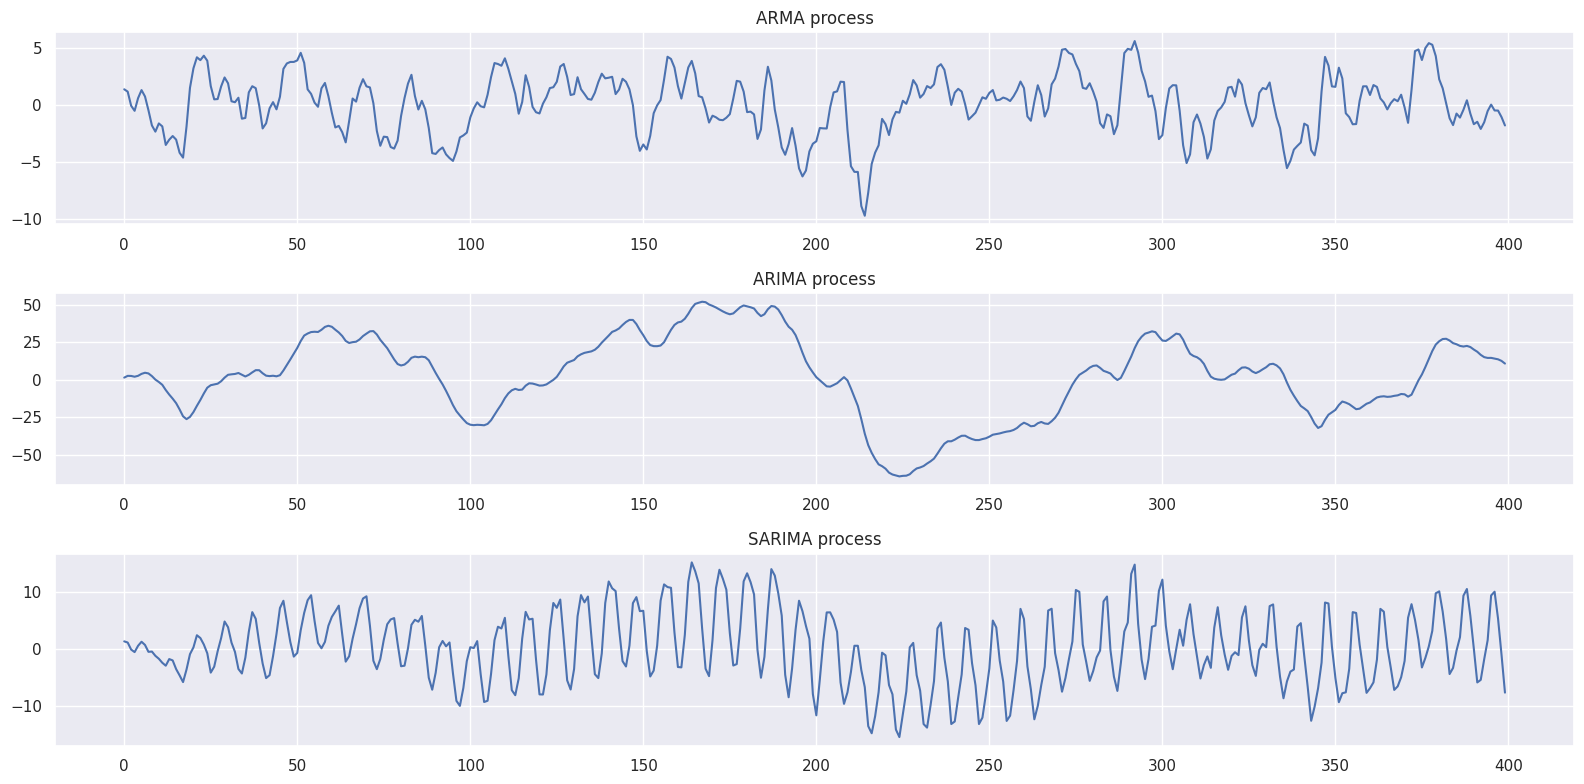

In [ ]:
# simulate test data
num_sample = 400
season_M = 8
arima_order = 1
season_order =1
arma_process = tsa.ArmaProcess([1,-0.8], [1,0.8])

#generate sample
arma_data = arma_process.generate_sample(num_sample)
arima_data = pm.utils.diff_inv(arma_data, 1, arima_order) #(data, lag, order of difference)
arima_data = arima_data[-num_sample:] # remove the leading zeroes
sarima_data = pm.utils.diff_inv(arma_data, season_M, season_order)
sarima_data = sarima_data[-num_sample:]

x = np.arange(0,num_sample, 1)
fig, ax = plt.subplots(3,1, figsize=(16,8), tight_layout=True)
ax[0].plot(x, arma_data); ax[0].title.set_text('ARMA process')
ax[1].plot(x, arima_data); ax[1].title.set_text('ARIMA process')
ax[2].plot(x, sarima_data); ax[2].title.set_text('SARIMA process')

In [ ]:
#plot acf and pacf
def plotACF_PACFsample(dataset, num_lag, title):
  fig,ax = plt.subplots(1,2,figsize=(16,4), tight_layout=True)
  _ = sm.graphics.tsa.plot_acf(dataset, lags=num_lag, title='Sample ACF', ax=ax[0])
  _ = sm.graphics.tsa.plot_pacf(dataset, lags=num_lag, title='Sample PACF', ax=ax[1])
  fig.suptitle(title, fontsize=16)

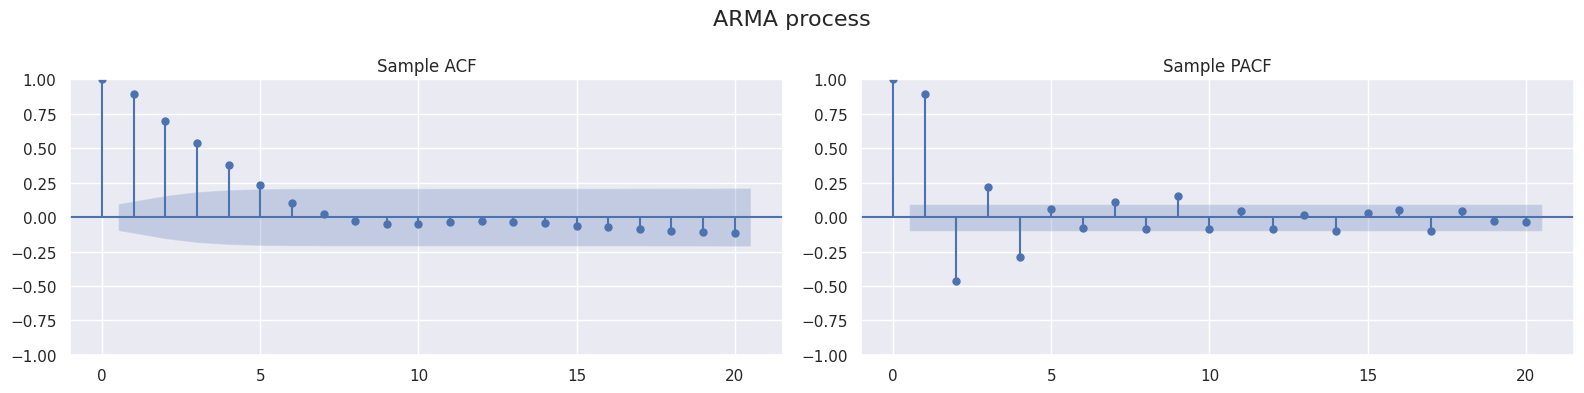

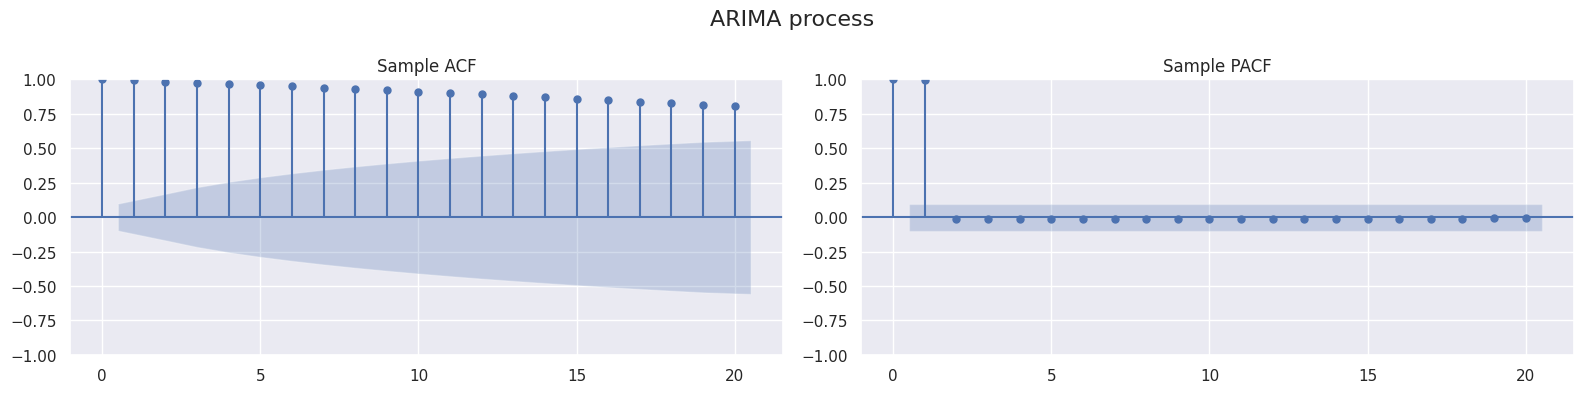

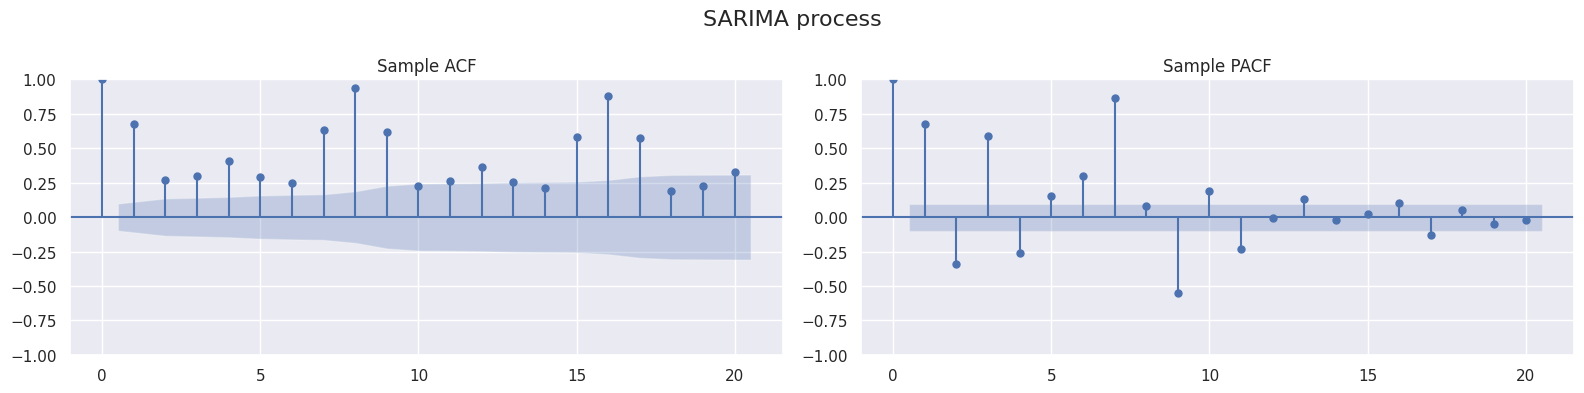

In [ ]:
num_lag = 20
plotACF_PACFsample(arma_data, num_lag, 'ARMA process')
plotACF_PACFsample(arima_data, num_lag, 'ARIMA process')
plotACF_PACFsample(sarima_data, num_lag, 'SARIMA process')

## Forecast (manual)

In [ ]:
# Construct my_df from simulated data. (Put here so I can manipulate the result easier)
my_timeframe = pd.date_range(start='1/22/2026', periods=num_sample, freq='D')
my_df = pd.DataFrame({
    'time' : my_timeframe,
    'data' : arima_data},  # put our data here.
)
my_df = my_df.set_index('time')
my_df.index.freq = 'D'


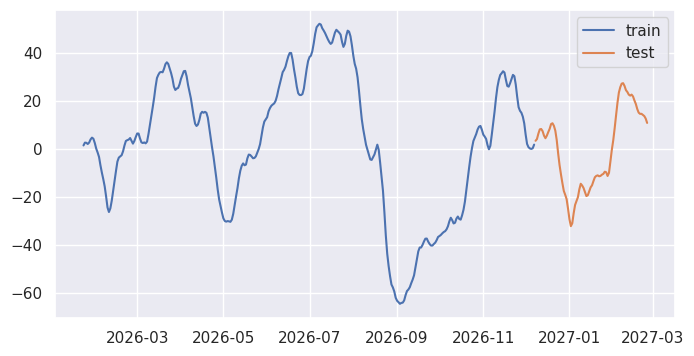

In [ ]:

num_sample = len(my_df['data'])
# Separate to train and test data
numTrain = int(0.8*num_sample)
MyTrainData = my_df[0:numTrain]
MyTestData =  my_df[numTrain:]
plt.plot(MyTrainData, label='train')
plt.plot(MyTestData, label='test')
plt.legend()

### STEP 1: Transform data (if necessary) and check for stationary

#### Option 1: Find d and D from the function in pmarima

There are functions in pmdarima that can check for d and D. However, take care that the function tests from the raw data. So if the dataset depends on external factor, we have to remove that external factor first. Let we start with the known result (simulated data)

In [ ]:
# for simulated data (no external factor)
print(f"The calculated order of ARIMA process is {pm.arima.ndiffs(arima_data, test='kpss')}")
print(f"The real difference order: {arima_order}")
print(f"The calculated seasonal order: {pm.arima.nsdiffs(sarima_data, m=season_M-2, test='ocsb')}")
print(f"The real seasonal order: {season_order}")

The calculated order of ARIMA process is 1
The real difference order: 1
The calculated seasonal order: 0
The real seasonal order: 1


Take care that the result will be wrong if we forget to remove the external factor.

In [ ]:
# This is incorrect because we have not removed the external factors.
print(pm.arima.ndiffs(np.log(train['sales']), test='kpss'))
print(pm.arima.nsdiffs(np.log(train['sales']), m=12, test='ocsb'))

1
0


In [ ]:
# This is the correct function
# Use the residual after removing the external factor
ols_resid = smf.ols('np.log(sales) ~ discount', data=train).fit().resid
# Hereis the correct d and D
print(pm.arima.ndiffs(ols_resid, test='kpss'))
print(pm.arima.nsdiffs(ols_resid, m=12, test='ocsb'))

1
1


In [ ]:
# General case
print(pm.arima.ndiffs(my_df['data'], test='kpss'))
print(pm.arima.nsdiffs(my_df['data'], m=12, test='ocsb'))

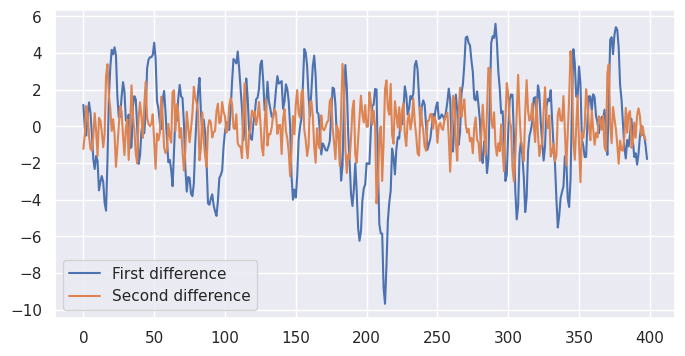

In [ ]:
# Take the difference (in case of ARIMA or SARIMA processes)
diff = pm.utils.diff(my_df['data'], 1, 1) #[data, lag, order of difference]
diff2 = pm.utils.diff(my_df['data'], 1, 2)
plt.plot(diff, label= 'First difference')
#plt.plot(my_df['data'].values,label= 'Original')
plt.plot(diff2, label='Second difference')
plt.legend()

####Check stationary.
*   ADF statistics is within the range of critical value
*   p-value not greater than 0.05

    





In [ ]:
myTest_dta = diff2

result = tsa.stattools.adfuller(myTest_dta, autolag="AIC") # change dta to the transformed diff
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'#Lags used: {result[2]}')
print(f'#observation: {result[3]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')


ADF Statistic: -8.243245473628743
p-value: 5.642699105425186e-13
#Lags used: 15
#observation: 382
Critial Values:
   1%, -3.4475850438570115
Critial Values:
   5%, -2.869135963767125
Critial Values:
   10%, -2.5708164748773332


####Check ACF and PACF.

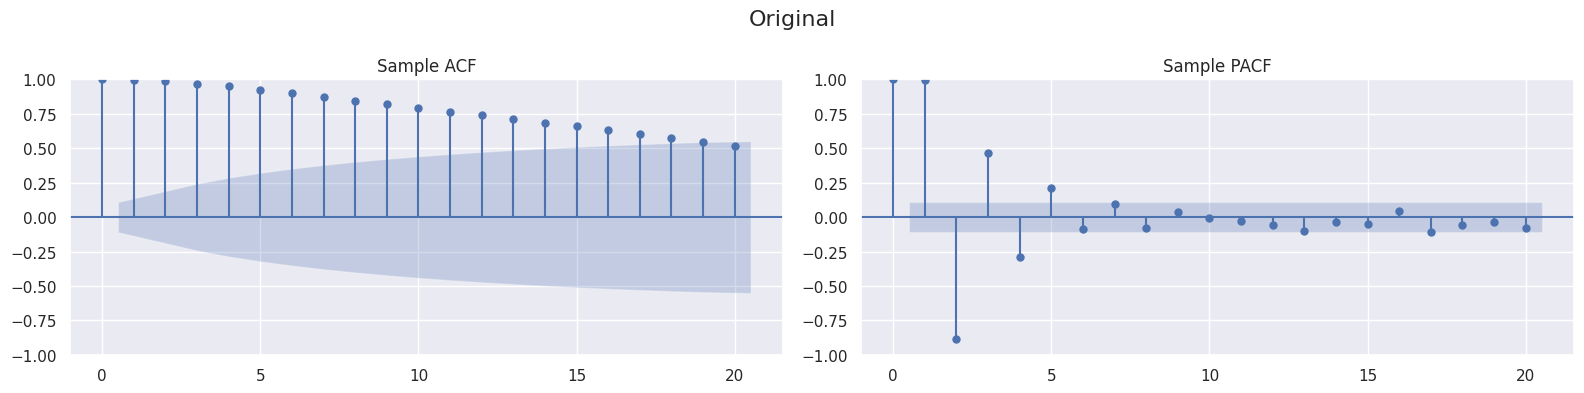

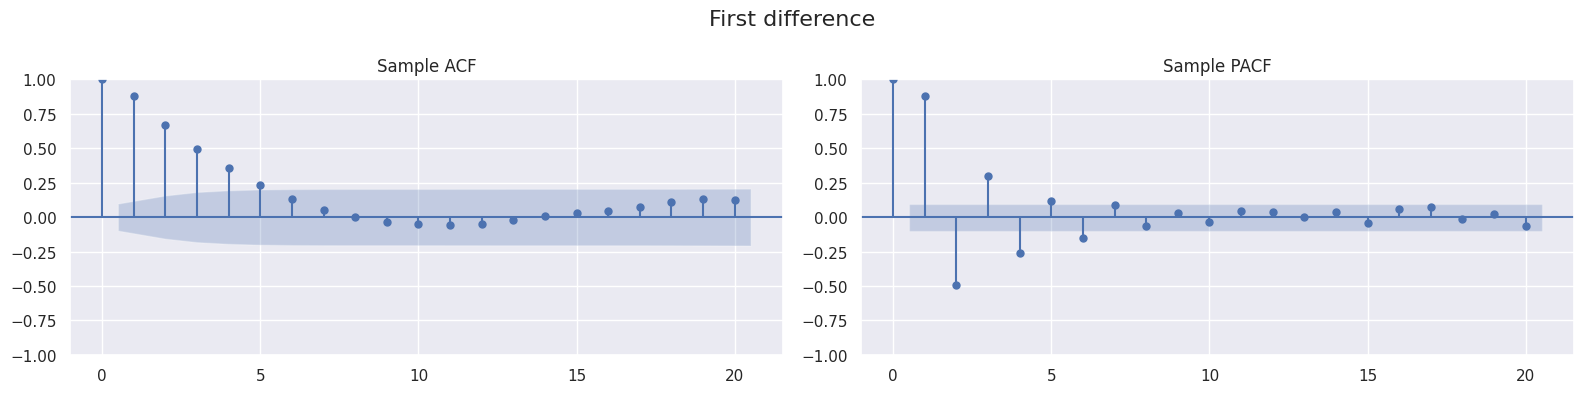

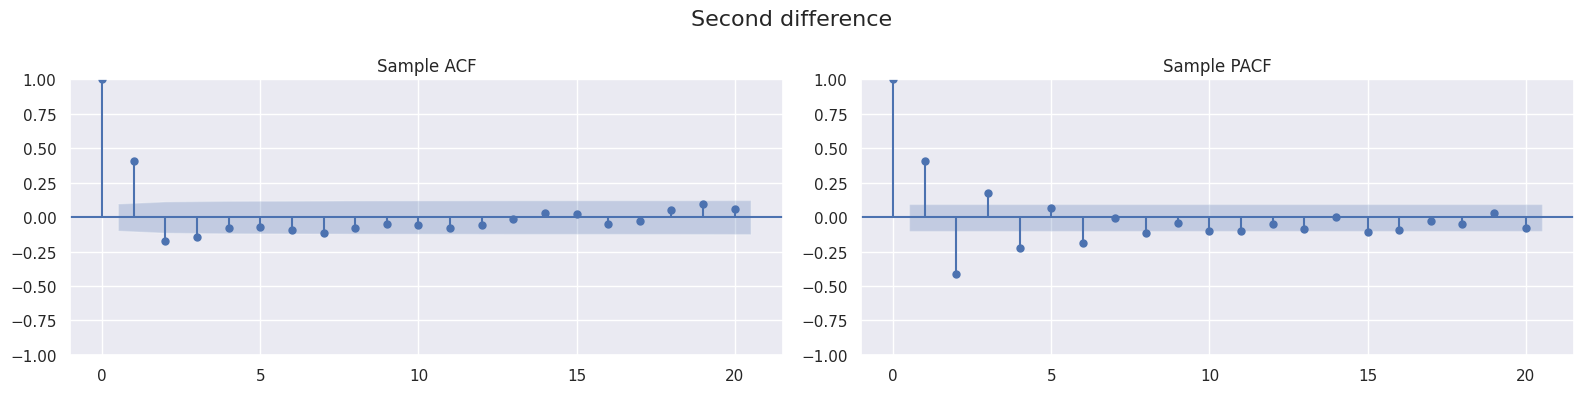

In [ ]:
num_lag =20
plotACF_PACFsample(MyTrainData['data'], num_lag, 'Original')
plotACF_PACFsample(diff, num_lag, 'First difference')
plotACF_PACFsample(diff2, num_lag, 'Second difference')

### STEP 2: Fit model

####Estimator without exogenous regressors (no external factor)

In [ ]:
MyModel =  tsa.SARIMAX(MyTrainData['data'], order=(1,1,1), # ARIMA (p,d,q)
                       seasonal_order=[0,0,0,0], # Seasonal (P,D,Q,S)
                       trend='c',
                       missing = 'none' # 'none' (no missing data), 'drop' the NAN, 'raise' error
                       ).fit()
MyModel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   data   No. Observations:                  320
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -427.588
Date:                Thu, 22 Jan 2026   AIC                            863.175
Time:                        02:23:28   BIC                            878.236
Sample:                    01-22-2026   HQIC                           869.190
                         - 12-07-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0113      0.098      0.116      0.908      -0.181       0.204
ar.L1          0.7923      0.036     21.920      0.000       0.721       0.863
ma.L1          0.8088      0.036     22.213      0.000       0.737       0.880
sigma2         0.8465      0.065     13.043      0.000       0.719       0.974
===================================================================================
Ljung-Box (L1) (Q):                   1.35   Jarque-Bera (JB):                14.26
Prob(Q):                              0.24   Prob(JB):                         0.00
Heteroskedasticity (H):               1.01   Skew:                            -0.46
Prob(H) (two-sided):                  0.94   Kurtosis:                         3.47
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#####Forecast result

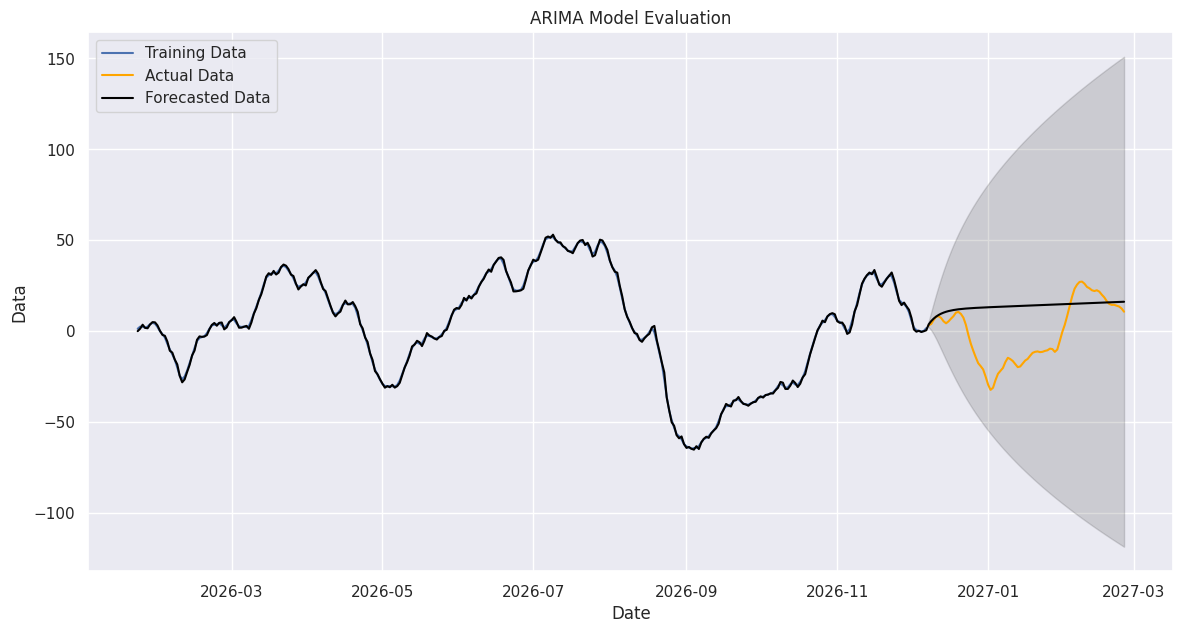

In [ ]:
nforecast = len(MyTestData['data'])
ndata = len(MyTrainData['data'])

test_forecast = MyModel.get_prediction(start = 0, end = ndata + nforecast -1)
test_forecast_series = pd.Series(test_forecast.predicted_mean)

# Create a plot to compare the forecast with the actual test data
plt.figure(figsize=(14,7))
plt.plot(MyTrainData['data'], label='Training Data')
plt.plot(MyTestData['data'], label='Actual Data', color='orange')
plt.plot(test_forecast_series, label='Forecasted Data', color='black')
plt.fill_between(MyTestData.index,
                 test_forecast.conf_int().iloc[ndata:nforecast+ndata, 0],
                 test_forecast.conf_int().iloc[ndata:nforecast+ndata, 1],
                 color='k', alpha=.15)
plt.title('ARIMA Model Evaluation')
plt.xlabel('Date')
plt.ylabel('Data')
plt.legend()
plt.show()

####Estimator with exogeneous regressor

In [ ]:
MyModel =  tsa.SARIMAX(np.log(train['sales']), order=(1,1,0), # ARIMA (p,d,q)
                       seasonal_order=[0,1,0,12], # Seasonal (P,D,Q,S)
                       exog = train['discount'],
                       trend='c',
                       missing = 'none' # 'none' (no missing data), 'drop' the NAN, 'raise' error
                       ).fit()
MyModel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              sales   No. Observations:                  108
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood                  78.202
Date:                            Thu, 22 Jan 2026   AIC                           -148.405
Time:                                    02:27:12   BIC                           -138.189
Sample:                                01-01-2010   HQIC                          -144.277
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0078      0.011     -0.689      0.491      -0.030       0.014
discount       0.7759      0.024     32.039      0.000       0.728       0.823
ar.L1         -0.4483      0.088     -5.094      0.000      -0.621      -0.276
sigma2         0.0113      0.002      7.494      0.000       0.008       0.014
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 1.30
Prob(Q):                              0.72   Prob(JB):                         0.52
Heteroskedasticity (H):               0.58   Skew:                            -0.02
Prob(H) (two-sided):                  0.13   Kurtosis:                         3.57
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#####Forecast result

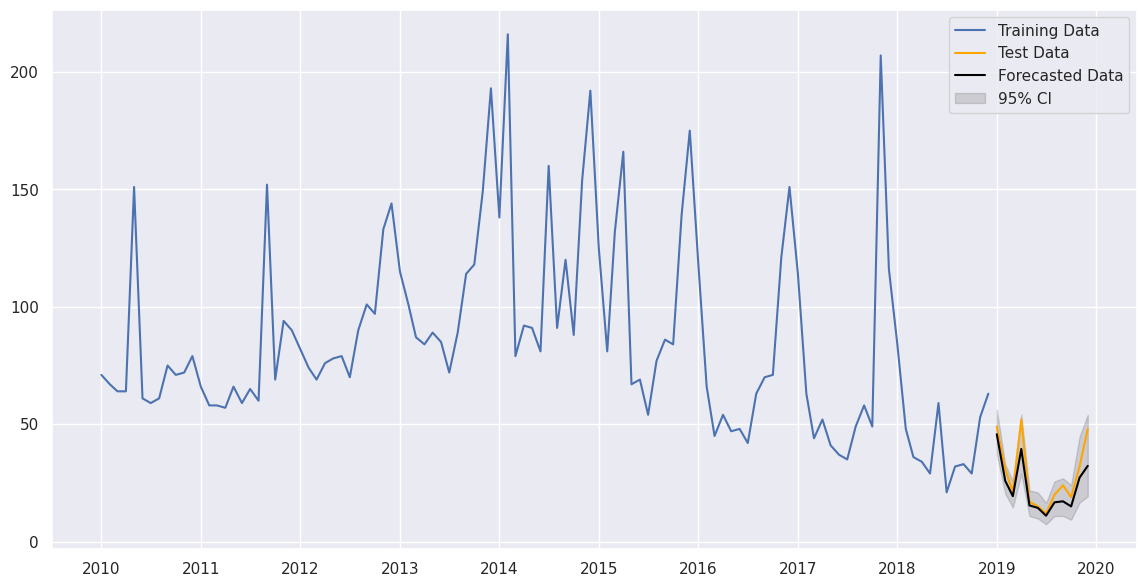

In [ ]:
nforecast = len(test['sales'])
ndata = len(train['sales'])

test_forecast = MyModel.get_forecast(nforecast, exog=test['discount'].values.reshape(-1,1))
conf_int = test_forecast.summary_frame(alpha=0.05).apply(np.exp)

# Create a plot to compare the forecast with the actual test data
plt.figure(figsize=(14,7))
plt.plot(train['sales'], label='Training Data')
plt.plot(test['sales'], label='Test Data', color='orange')
plt.plot(conf_int['mean'], label='Forecasted Data', color='black')
plt.fill_between(test.index,
                 conf_int['mean_ci_lower'],
                 conf_int['mean_ci_upper'],
                 alpha = 0.15, color='k',
                 label='95% CI')

plt.legend()
plt.show()

In [ ]:
print(nforecast)
print(ndata)
print(len(ts_sales_bj['discount']))
print(test_forecast_series.head(10))

##Forecast (auto_arima)

In [ ]:
mod_sarimax_best = pm.arima.auto_arima(
    y = np.log(train['sales']),                  # data
    X = train['discount'].values.reshape(-1,1),  # external value
    test='kpss',              # KPSS test to find d
    seasonal_test='ocsb',     # OCSB test to find D
    criterion='AIC',          # AIC to choose model
    m=12,                     # M=12
    max_p=2, max_q=2, max_P=2, max_Q=2,              # max order
    start_p=0, start_q=0, start_Q=0, start_P=0,      # initial order
    stepwise=False,          # Use stepwise or not (quicker if we use)
    n_jobs=-1,               # Use every available core
    maxiter=5000,            # Maximum iteration for fitting
    with_intercept=False,    # Model without interception
    solver='nm'              # Solver type)
)

KeyboardInterrupt: 

In [ ]:
print(mod_sarimax_best.summary())